## Proyek Akhir Sikomat 2022 (Simulasi Hubungan Antara Predator dan Mangsa pada Variasi Densitas Populasi)
Anggota Kelompok:
1. Nicholas Dustin (10121035)
2. Adilla Rifqi Muhammad (10121047)
3. Melvan Safero Lee (10121063)
4. Muhammad Ahkam Shafy (10121069)
5. Bryan Guok (10121091)

Library Digunakan

In [ ]:
from pickle import TRUE
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import colors
import matplotlib
import matplotlib.image as mpimg
import matplotlib.animation as animation
from IPython.display import HTML  # for embedded matplotlib animation
from math import *

# Nomor 1 (Teknik Cellular Automata)

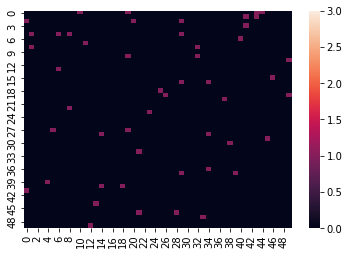

In [ ]:
# Kasus 1: Model CA

# Keterangan angka pada matriks lingkungan
EMPTY = 0
PREY = 1
PREDATOR = 2
PREDATOR_ATE = 3

# Fungsi Inisialisasi Matriks Lingkungan dengan status lapar
def initHunger(m = 50, n = 50): #Dibuat ukuran sebesar 50x50 grid
  matHunger = [[0 for i in range(n)] for j in range(m)] #Array matriks lingkungan status lapar
  return matHunger

#Fungsi Inisialisasi Matriks Lingkungan
def initMatrix(probPrey, probPred, matHunger):
  m = len(matHunger) #Jumlah kolom matriks lingkungan
  n = len(matHunger[0]) #Jumlah baris matriks lingkungan
  mat = [[0 for i in range(n)] for j in range(m)] #Array matriks lingkungan
  for i in range(m):
    for j in range(n):
      rnd = random.random() #Bangkitkan bilangan 0 sampai 1
      if rnd < probPrey: #Mengisi populasi mangsa dengan peluang mangsa dimasukkan
        mat[i][j] = PREY
      elif rnd < probPrey + probPred: #Mengisi populasi predator dengan peluang mangsa dimasukkan
        mat[i][j] = PREDATOR
        matHunger[i][j] = 0 #Atur status lapar pada predator
      else:
        mat[i][j] = EMPTY #Sisanya kosong
  return mat

def changeState(mat, matHunger): #Prosedur Ketentuan keadaan
  neighbours = [(0, 1), (1, 0), (-1, 0), (0, -1), (1, 1), (1, -1), (-1, 1), (-1, -1)] #Menggunakan ketetanggaan Moore untuk mengecek sel tetangga
  hunger = True
  for i in range(len(mat)):
    for j in range(len(mat[0])):
      if mat[i][j] is PREDATOR: #Jika posisi matriks predator
        for neighbour in neighbours:
          x, y = neighbour #Atur posisi x dan y menjadi tetangga
          if -1 < (i + x) < len(mat) and -1 < (j + y) < len(mat[0]) and matHunger[i][j] != 0: #Jika posisi predator/mangsa berada di dalam matriks lingkungan
            if mat[i+x][j+y] is PREY: #Jika sel tetangga terdapat mangsa
              mat[i+x][j+y] = EMPTY #Mangsa ditangkap
              mat[i][j] = PREDATOR_ATE #Predator menangkap mangsa
              matHunger[i][j] = 0 #Atur status lapar pada predator menjadi 0
              hunger = False
              break
          else:
            hunger = True #Jika tidak ada sel tetangga berisi mangsa
        if hunger is True:
          matHunger[i][j] += 1 #Menambahkan nilai lapar pada predator 1 iterasi seiring berjalannya simulasi
      elif mat[i][j] is PREDATOR_ATE: #Setelah dimangsa
        mat[i][j] = PREDATOR #Posisinya berubah menjadi predator
        matHunger[i][j] = 0 #Atur nilai kelaparan pada predator menjadi 0

  starvation(mat, matHunger) #Panggil fungsi status lapar pada predator

  return mat

#Fungsi pergerakan mangsa/predator
def move(mat, matHunger): # Masalah 1: pergerakan predator/mangsa
  steps = [(0,1), (1, 0), (0, -1), (-1, 0)] #List arah langkah

  for i in range(len(mat)):
    for j in range(len(mat[0])):
      if mat[i][j] is not EMPTY: #Jika terdapat ketetanggaan sel
        step = random.choice(steps) #Memilih arah langkah secara acak
        x, y = step #x: baris, y: kolom

        if -1 < (i + x) < len(mat) and -1 < (j + y) < len(mat[0]) and mat[i+x][j+y] is EMPTY: #Jika berada di dalam matriks lingkungan dan sel tetangga kosong
          mat[i+x][j+y] = mat[i][j] #Individu tidak akan bergerak
          matHunger[i+x][j+y] = matHunger[i][j] #Status lapar tetap
          mat[i][j] = EMPTY
          matHunger[i][j] = 0
        # Predator akan makan lagi pada iterasi t+2


      else:
        mat[i][j] = EMPTY
  return mat

#Fungsi status lapar untuk predator
def starvation(mat, matHunger):
  for i in range(len(matHunger)):
    for j in range(len(matHunger[0])):
      if matHunger[i][j] > 4: #Jika predator berjalan lebih dari 4 iterasi tidak ada makanan
        mat[i][j] = EMPTY

# Algoritma Utama
H = initHunger()
A = initMatrix(0.04, 0.025, H) #Untuk nomor 1b gunakan variasi probabilitas densitas populasi dengan peningkatan 0.04 untuk mangsa dan 0.025 untuk predator
B = changeState(move(A, H), H)
simulLen = 50 #Simulasi selama 50 iterasi

# Menyiapkan figure, heatmap
fig = plt.figure()
ax = sns.heatmap(A, vmin=0, vmax=3)

# Fungsi init
def init():
    plt.clf()
    ax = sns.heatmap(B, vmin=0, vmax=3)
    return None

# Fungsi iterasi animasi
def animate(i):
    plt.clf()
    global B
    B = changeState(move(B, H), H)
    ax = sns.heatmap(B, vmin=0, vmax=3)
    ax.set_title(f"iterasi ke-{i}")
    return None

# Fungsi init
anim = animation.FuncAnimation(fig, animate, frames=range(simulLen), blit=False, interval=200, init_func=init)

# Kode tambahan jika dijalankan di colab/jupyter
from matplotlib import rc
from IPython.display import HTML
rc('animation', html='jshtml')
anim

# Nomor 2 (Teknik Agent-based Model)

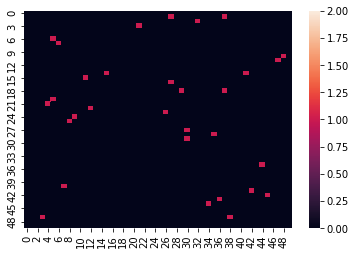

In [ ]:
# Kasus 2: Model ABM

# Keterangan angka
EMPTY = 0
PREY = 1
PREDATOR = 2

# Fungsi inisialisasi agen lingkungan
def initAgentMat(agents, probPrey, probPred, m, n):
  mat = [[0 for i in range(m)] for j in range(n)]

  for i in range(len(mat)):
    for j in range(len(mat[0])):
      rnd = random.random() #Bangkitkan angka 0 sampai 1

      if rnd < probPrey: #Mengisi populasi mangsa dengan peluang mangsa dimasukkan
        agents.append([PREY, i, j, 0]) # Jenis, baris, kolom, status lapar, pada prey diisi 0 dan tidak akan diupdate
      elif rnd < probPrey + probPred: #Mengisi populasi predator dengan peluang predator dimasukkan
        agents.append([PREDATOR, i, j, 0]) # Pada predator status lapar akan diupdate di fungsi lain

  for agent in agents:
    x, y = agent[1], agent[2] #Atur angka 1 dan 2 sebagai posisi x dan y
    mat[x][y] = agent[0] #Atur angka nol sebagai peran

  return mat

#Fungsi pergerakan predator/mangsa
def move(agents, mat): #Prosedur pergerakan
  steps = [(0,1), (1, 0), (0, -1), (-1, 0)] #List arah langkah dengan ketetanggaan von Neumann

  for agent in agents:
    step = random.choice(steps) #Pilih arah langkah secara acak
    x, y = step #x: baris, y: kolom

    if -1 < (agent[1] + x) < len(mat)-1 and -1 < (agent[2] + y) < len(mat[0])-1 and mat[agent[1]+x][agent[2]+y] is EMPTY: #Jika berada di dalam matriks lingkungan dan posisinya kosong
      mat[agent[1]][agent[2]] = EMPTY
      agent[1] += x #Eksekusi agen bergerak searah x
      agent[2] += y #Eksekusi agen bergerak searah y

#Fungsi memangsa
def preying(agents, mat):
  neighbours = [(0, 1), (1, 0), (-1, 0), (0, -1), (1, 1), (1, -1), (-1, 1), (-1, -1)] #List keberadaan sel tetanggsa dengan ketetanggaan Moore
  hunger = True

  for agent in agents:
    if agent[0] is PREDATOR: #Jika agen adalah predator
      for neighbour in neighbours:
        x, y = neighbour #Atur posisi x dan y sebagai sel tetangga

        if 0 < (agent[1] + x) < len(mat) and 0 < (agent[2] + y) < len(mat[0]): #Jika agen berada di dalam matriks lingkungan
          if mat[agent[1] + x][agent[2] + y] is PREY and agent[3] != 0: # Masih belum mengremove agent yang adalah prey
            agent[3] = 0 # Status lapar
            mat[agent[1] + x][agent[2] + y] = EMPTY #Agen berada di sel kosong

            for remove_prey in agents:
              if remove_prey[1] == agent[1] + x and remove_prey[2] == agent[2] + y: #Menghapus mangsa ketika dimangsa
                agents.remove(remove_prey)

            hunger = False #Predator akan makan lagi pada iterasi t+2
            break

        else:
          hunger = True #Jika tidak ada mangsa dalam sel tetangga

      if hunger is True:
        agent[3] += 1 #Menambahkan status kelaparan dengan 1

  for agent in agents: #Loop wajib dipisah dengan yang di atas dengan penjelasan kodingan di bawah code cell setelah ABM ini
    if agent[3] > 4: # NIM 091 --> A = 3 + 1 --> predator mati setelah 4 iterasi mengalami kelaparan
      mat[agent[1]][agent[2]] = EMPTY #Hapus agen berperan predator menjadi agen kosong
      agents.remove(agent)
#Fungsi mengupdate
def updateMat(agents, mat):
  preying(agents, mat) #Panggil fungsi memangsa
  move(agents, mat) #Panggil fungsi pergerakan predator/mangsa

  for agent in agents:
    mat[agent[1]][agent[2]] = agent[0]

  return mat

# Algoritma Utama
agents = [] #Inisialisasi kedua agen, yakni predator dan mangsa
C = initAgentMat(agents, 0.04, 0.025, 50, 50) #Untuk nomor 2b gunakan probabilitas densitas populasi variasi dengan meningkatkan 0.04 untuk probPrey dan 0.025 untuk probPred setiap simulasi berikutnya
D = updateMat(agents, C)
simulLen = 50 #Siumlasi selama 50 iterasi

# Menyiapkan figure, heatmap
fig = plt.figure()
ax = sns.heatmap(C, vmin=0, vmax=2)

# Fungsi init
def init():
    plt.clf()
    ax = sns.heatmap(C, vmin=0, vmax=2)
    return None

# Fungsi iterasi animasi
def animate(i):
    plt.clf()
    global D

    if i == 0:
      D = updateMat(agents, C)
    else:
      D = updateMat(agents, D)

    ax = sns.heatmap(D, vmin=0, vmax=2)
    ax.set_title(f"iterasi ke-{i}")
    return None

# Fungsi init
anim = animation.FuncAnimation(fig, animate, frames=range(simulLen), blit=False, interval=200, init_func=init)

# Kode tambahan jika dijalankan di colab/jupyter
from matplotlib import rc
from IPython.display import HTML
rc('animation', html='jshtml')
anim